This Jupyter Notebook shows the workflow of the best optimized LSTM model to approximate commitor (optimalRC).

Firstly we must import and load the dihedral angel data with file name csddih. This is a fortran file and requires a specific funtion to read the dihedral angles. The rmsd file is also imported, however not used withing this workflow. The file q_traj is also loaded. This is the trajectory of the 'ground truth' committor targets. The shapes of csdih and q_traj are printed , to confirm they have the same number of frames

In [1]:
import numpy as np
from scipy.io import FortranFile

# Load RMSD (optional, already done in your earlier code)
with open('../2f4kpnas380.CArmsd') as f:
    rmsd = np.array([float(l.split()[1]) for l in f], dtype=np.float32)

# Function to read your dihedral data
def read_dih(name):
    f = FortranFile(name, 'r')
    rec = f.read_record(np.dtype('i4'))
    nsets, ndih = rec[0], rec[1]
    csdih = np.zeros((nsets, ndih), dtype='f4')
    csdih = f.read_record(np.dtype('f4')).reshape((ndih, nsets)).T
    f.close()
    return csdih

# Load dihedral angles
csdih = read_dih('../csdih')

# Load committor targets
q_traj = np.load('q_traj.npy')


# Check shapes
print('csdih shape:', csdih.shape)
print('q_traj shape:', q_traj.shape)


csdih shape: (1509392, 136)
q_traj shape: (1509392,)


Function to check that GPU is avaialbe, as the neural network will not run on local CPU.

In [2]:
import torch
print(torch.cuda.is_available())  # should print True if GPU is ready


True


Import Sergei's optimalrcs library, in order to run validation plots. 

In [3]:
import sys
sys.path.append('/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/')
import optimalrcs,metrics,plots

The data (csdih) is ran through the LSTM model using q_traj as a target, with a loss function that utilises MSE to approximate this target. This optimized network uses a sequence history of 7 and 88 hidden layers. It passes the output through a sigmoid function, forcing the output to be between 0 and 1, as the committor always lies within this range. 

Epoch 020: Train 0.000049, Val 0.000440
Training complete. Best val loss: 0.0004402696784859382


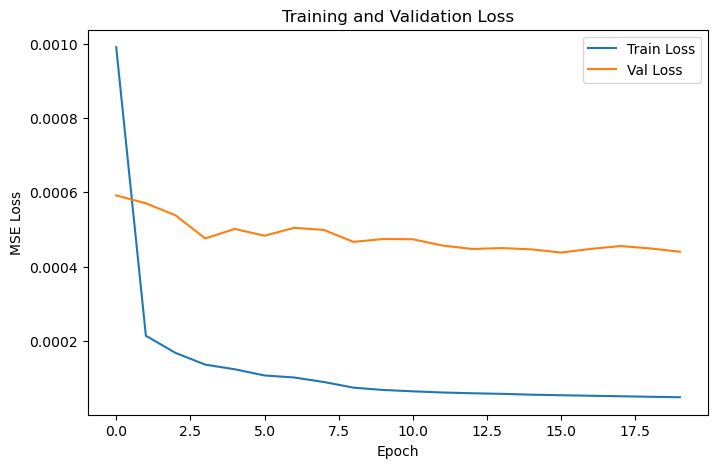

Pearson correlation on test set: 0.9964


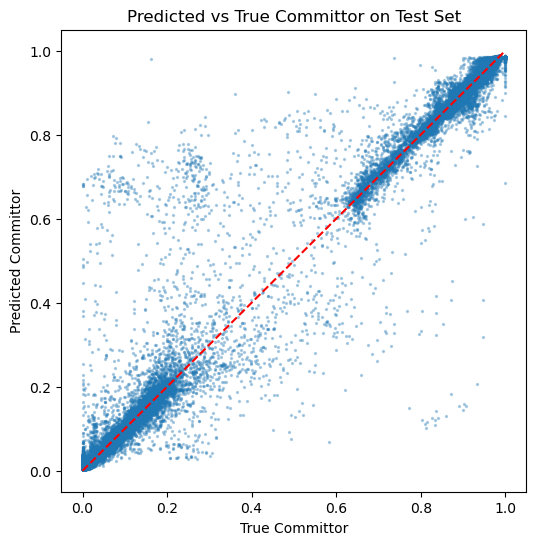

Generating full trajectory committor predictions...
seed_r shape: (1509385,)


In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



# ============================
# 1. Dataset Loader
# ============================
class ProteinDataset(Dataset):
    def __init__(self, features, targets, window=7):
        self.features = features
        self.targets = targets
        self.window = window
        self.length = len(features) - window

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.window]
        y = self.targets[idx + self.window - 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# ============================
# 2. LSTM Model
# ============================
class LSTMCommittor(nn.Module):
    def __init__(self, input_dim=136, hidden_dim=88, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 44),
            nn.ReLU(),
            nn.Linear(44, 1),
            nn.Sigmoid()      # ★ 
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]
        out = self.fc(h_last).squeeze(1)
        return out


# ============================
# 3. Training Utilities with Loss Tracking
# ============================
def train_model(model, train_loader, val_loader, n_epochs=20, lr=1e-3, device='cuda'):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    


    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(x)

        avg_train = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_loss += criterion(model(x), y).item() * len(x)

        avg_val = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val)
        scheduler.step(avg_val)




    print(f"Epoch {epoch+1:03d}: Train {avg_train:.6f}, Val {avg_val:.6f}")

    if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), 'best_lstm_committor.pt')

    print("Training complete. Best val loss:", best_val_loss)

    # Plot training and validation loss
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig("loss_curveLSTMOPT.png", dpi=300, bbox_inches='tight')
    plt.show()

# ============================
# 4. Usage Example
# ============================
csdih = np.load('csdih.npy', mmap_mode='r')
q_traj = np.load('q_traj.npy', mmap_mode='r')

# Normalize features
mean = np.mean(csdih, axis=0)
std = np.std(csdih, axis=0) + 1e-8
csdih_norm = (csdih - mean) / std

# Train/val/test split (time-ordered)
N = len(csdih_norm)
train_end = int(0.8 * N)
val_end = int(0.9 * N)

train_ds = ProteinDataset(csdih_norm[:train_end], q_traj[:train_end])
val_ds = ProteinDataset(csdih_norm[train_end - 7:val_end], q_traj[train_end - 7:val_end])
test_ds = ProteinDataset(csdih_norm[val_end - 7:], q_traj[val_end - 7:])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTMCommittor(input_dim=136)
train_model(model, train_loader, val_loader, n_epochs=20, device=device)

# ============================
# 5. Test Set Evaluation
# ============================
model.load_state_dict(torch.load('best_lstm_committor.pt'))
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Compute Pearson correlation
corr, _ = pearsonr(all_preds, all_targets)
print(f"Pearson correlation on test set: {corr:.4f}")

# Scatter plot predicted vs true committor
plt.figure(figsize=(6,6))
plt.scatter(all_targets, all_preds, alpha=0.3, s=2)
plt.xlabel('True Committor')
plt.ylabel('Predicted Committor')
plt.title('Predicted vs True Committor on Test Set')
plt.plot([0,1],[0,1], 'r--')  # diagonal
plt.savefig("predicted_vs_trueLSTMOPT.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================
# 6. Full Trajectory Inference for Validation
# ============================
print("Generating full trajectory committor predictions...")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.load_state_dict(torch.load('best_lstm_committor.pt'))
model.to(device)
model.eval()

window = 7
dataset_full = ProteinDataset(csdih_norm, np.zeros_like(q_traj), window=window)
loader_full = torch.utils.data.DataLoader(dataset_full, batch_size=1024, shuffle=False)

preds = []
with torch.no_grad():
    for x, _ in loader_full:
        x = x.to(device)
        y_pred = model(x)
        preds.append(y_pred.cpu().numpy())

seed_r = np.concatenate(preds).flatten()
print("seed_r shape:", seed_r.shape)



Results show that the network was able to approximate the commitor , with a pearson correlation on the test set of 0.9969. While this may appear accurate, there are still many frames which are not a close numerical match. The training loss curves show that the model is overfitting slightly, as it drops, raises slightly but does then level out. To test if the points that have approximated are those that capture the meaningful information within the system, the seed_r (trajectory produced by the LSTM) should be plotted as a function of free energy, as well as being passed through the validation criterion (Zq). 

The code below defines i_traj (step) and t_traj (time), in order to call the validtion plots (q2). 

In [12]:
i_traj=np.ones_like(rmsd)
t_traj=np.asarray(range(len(rmsd)))
print (i_traj[:10])
print (t_traj[:10])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0 1 2 3 4 5 6 7 8 9]


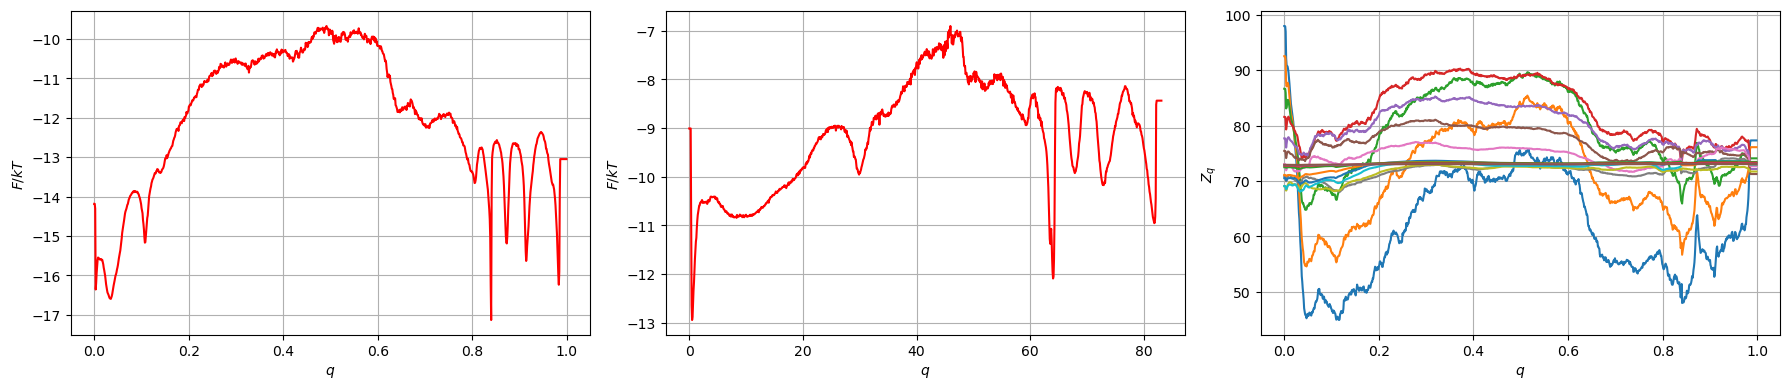

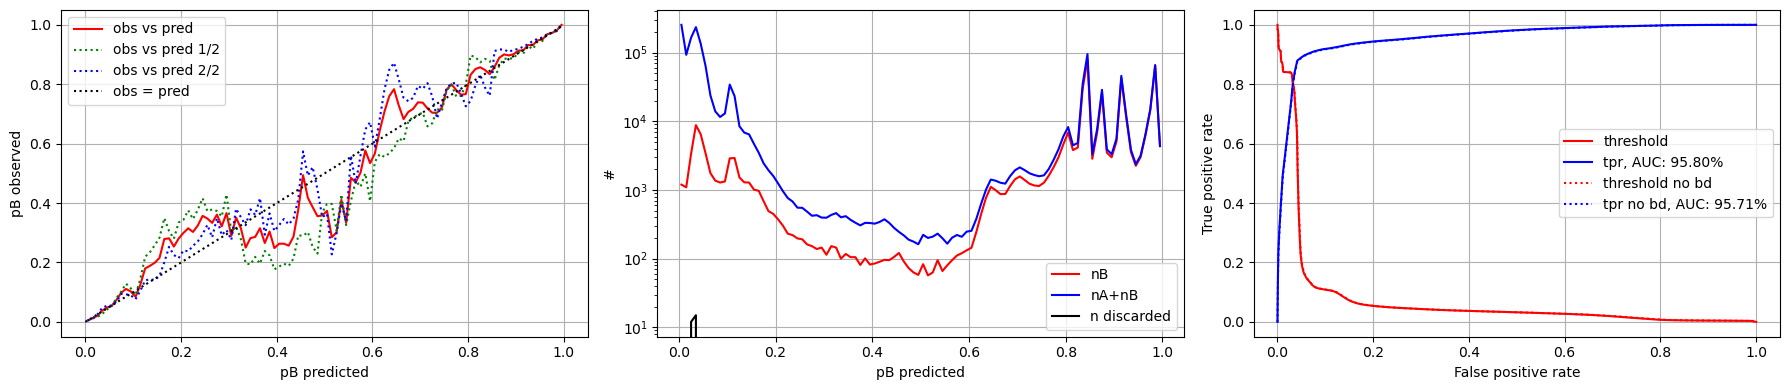

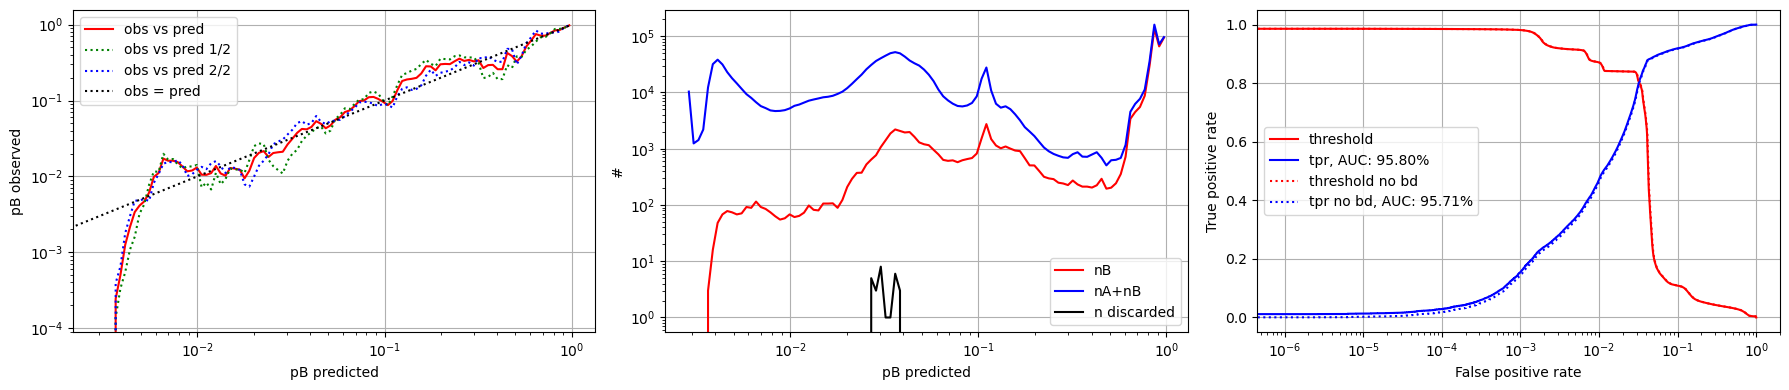

In [13]:
import matplotlib.pyplot as plt
from unittest.mock import patch

# --- 1. Define your q2 object (Ensure slicing matches seed_r length!) ---
# Note: Double check that len(rmsd[7:]) is exactly equal to len(seed_r)
# If using a window of 6 centered, you likely need rmsd[3:-3] as discussed.
q2 = optimalrcs.CommittorNE(
    boundary0=rmsd[7:] > 10.5,
    boundary1=rmsd[7:] < 1.0,
    i_traj=i_traj[7:],
    t_traj=t_traj[7:],
    seed_r=seed_r
)

# --- 2. Save Free Energy Profiles (FEPs) ---
with patch('matplotlib.pyplot.show'):
    q2.plots_feps()          # Generate plot (plt.show is blocked)
    fig = plt.gcf()          # Get Current Figure
    fig.savefig('FEP_Profiles.png', dpi=300, bbox_inches='tight') # Save High Quality
    plt.show()               # Show in notebook manually

# --- 3. Save Predicted vs Observed ---
with patch('matplotlib.pyplot.show'):
    q2.plots_obs_pred()
    fig = plt.gcf()
    fig.savefig('Pred_vs_Obs.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. Save Predicted vs Observed (Log Scale) ---
with patch('matplotlib.pyplot.show'):
    q2.plots_obs_pred(log_scale=True)
    fig = plt.gcf()
    fig.savefig('Pred_vs_Obs_Log.png', dpi=300, bbox_inches='tight')
    plt.show()

Validation plots using code from optimalrcs library. 

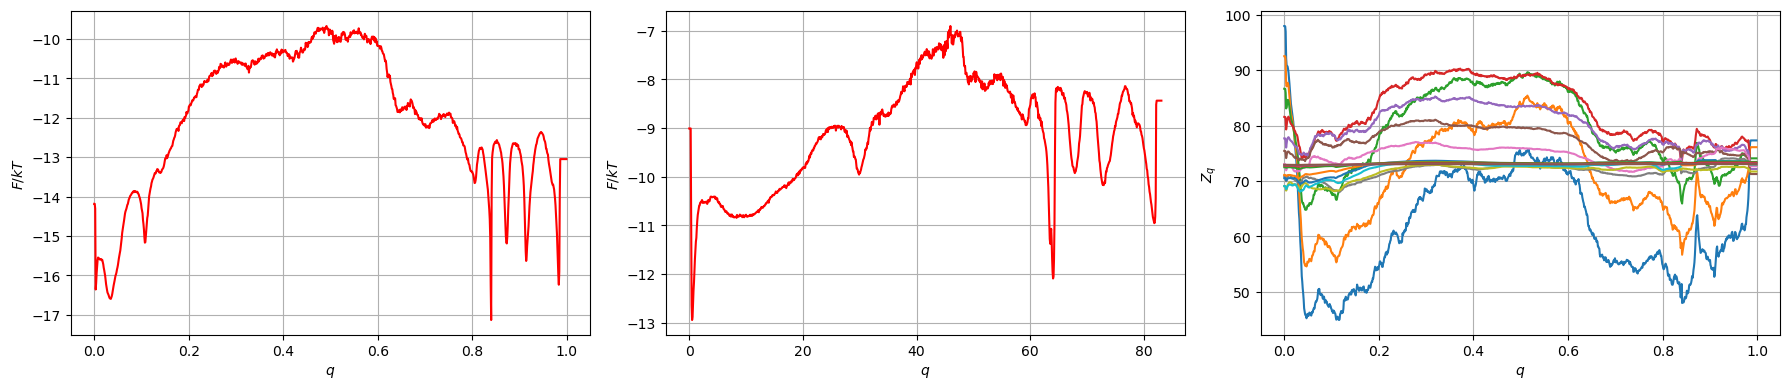

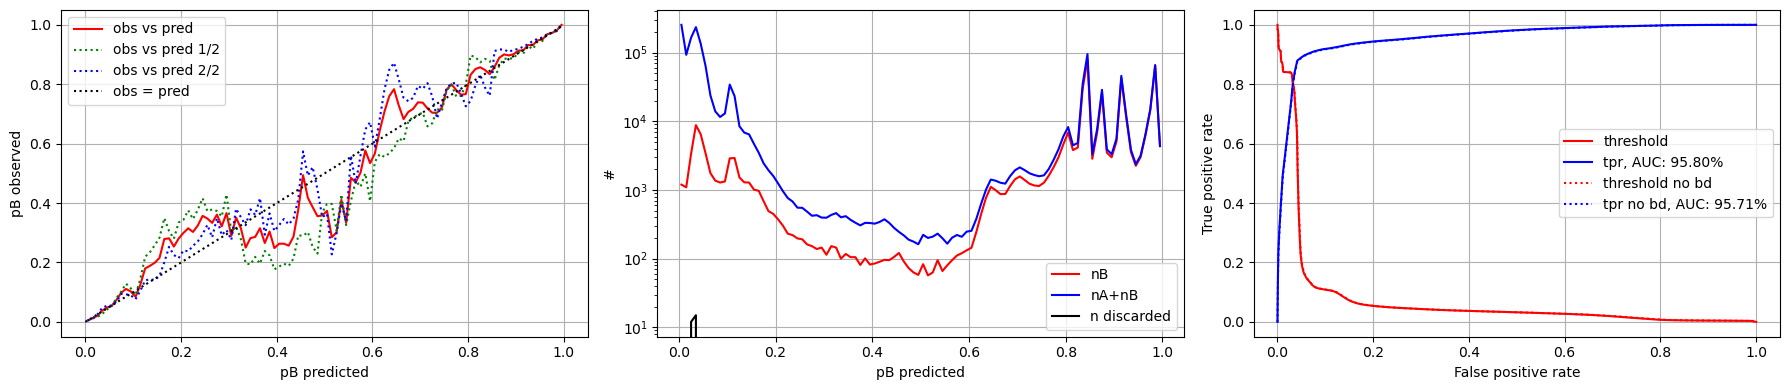

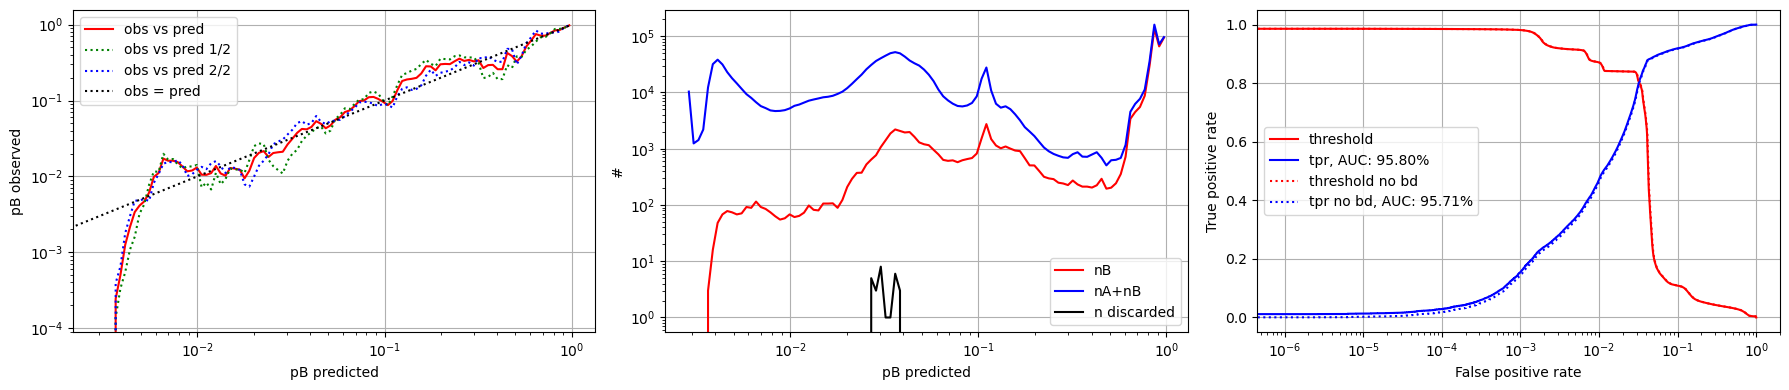

In [14]:
q2=optimalrcs.CommittorNE(boundary0=rmsd[7:]>10.5,boundary1=rmsd[7:]<1.0, i_traj=i_traj[7:], t_traj=t_traj[7:], seed_r=seed_r)
q2.plots_feps()
q2.plots_obs_pred()
q2.plots_obs_pred(log_scale=True)

The first 2 plots show the seed_r trajectory as a function of free energy. In the following cell this is overlayed with the FEP of q_traj (optimal), to see the difference in depth and hight of metastable basins and transition regions. The third plot is the commitor as a function of Zq. The true committor should remain completely constant. This plot shows some level of continuity, however has very obvious fulctionations, particularly in regions where there is more data (0-0.2, 0.8-1.0). The blue line sat below the average could indicate overfitting, or could be a result of the systems memory. 

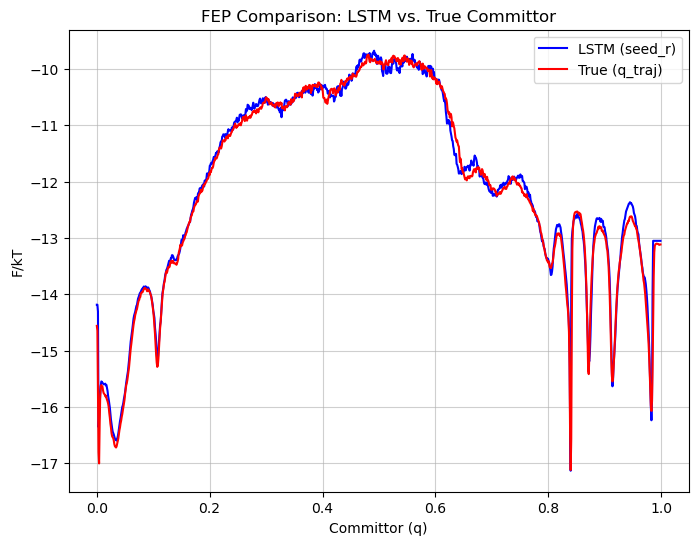

In [16]:
import matplotlib.pyplot as plt
from optimalrcs import plots

# 1. Slice the TRUE committor to match the Transformer's output length
# (Assuming window=6 as per your code)
q_traj_true = q_traj[7:] 

# 2. Create a single figure
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Plot YOUR Prediction (seed_r)
# We plot this first (Blue)
plots.plot_fep(ax, q2.r_traj, i_traj=q2.i_traj, t_traj=q2.t_traj)

# 4. Plot the TRUE Reference (q_traj) on the SAME axis
# We plot this second (Red)
plots.plot_fep(ax, q_traj_true, i_traj=q2.i_traj, t_traj=q2.t_traj)

# 5. Customize the lines for clarity
lines = ax.get_lines()
if len(lines) >= 2:
    # Set the Transformer/LSTM prediction to Blue
    lines[0].set_color('blue')
    lines[0].set_label('LSTM (seed_r)') 
    
    # Set the True Committor to Red
    lines[-1].set_color('red')
    lines[-1].set_label('True (q_traj)')
    
    ax.legend()

# 6. Add Grid and Labels
ax.grid(True, which='both', linestyle='-', alpha=0.6)
ax.set_ylabel('F/kT')
ax.set_xlabel('Committor (q)')
plt.title("FEP Comparison: LSTM vs. True Committor")

# --- SAVE COMMAND GOES HERE ---
# dpi=300: High resolution (good for papers)
# bbox_inches='tight': Prevents axis labels from being cut off
fig.savefig('FEP_Comparison_OverlayCORRECT.png', dpi=300, bbox_inches='tight')

# 7. Show the plot
plt.show()

This overalayed plot shows the best agreement with a FEP with regard to root mean squared error (see below). It accurately maps the path of the transition region. However, there are obvious discrepencies in free energy when the committor is equal to 0.0, as well as in the peaks and troughs of the basins in the q=0.8-1.0 region. 

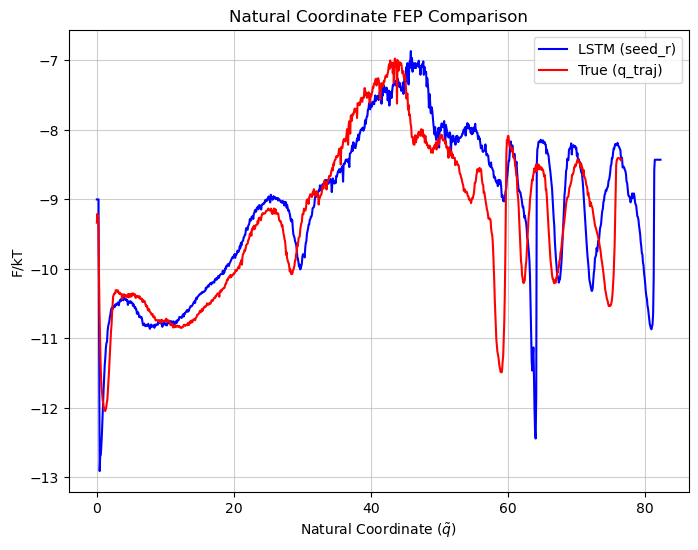

In [10]:
import matplotlib.pyplot as plt
import cupy as cp  # Import CuPy to handle GPU arrays
from optimalrcs import plots

# 1. Slice the TRUE committor (CPU side)
# (Assuming window=6 as per your previous context)
q_traj_cpu = q_traj[7:]

# 2. Convert to GPU Array for the library
# This fixes the "NotImplementedError"
q_traj_true = cp.asarray(q_traj_cpu)

# 3. Create a single figure
fig, ax = plt.subplots(figsize=(8, 6))

# 4. Plot YOUR Transformer Prediction (Natural Coordinate)
# q2.r_traj is likely already on GPU inside the q2 object
plots.plot_fep(ax, q2.r_traj, i_traj=q2.i_traj, t_traj=q2.t_traj, natural=True)

# 5. Plot the TRUE Reference (Natural Coordinate)
# Now passing the GPU array 'q_traj_true'
plots.plot_fep(ax, q_traj_true, i_traj=q2.i_traj, t_traj=q2.t_traj, natural=True)

# 6. Customize the lines
lines = ax.get_lines()
if len(lines) >= 2:
    lines[0].set_color('blue')
    lines[0].set_label('LSTM (seed_r)')  # Updated label to match your model type
    lines[-1].set_color('red')
    lines[-1].set_label('True (q_traj)')
    ax.legend()

# 7. Final Polish
ax.grid(True, which='both', linestyle='-', alpha=0.6)
ax.set_ylabel('F/kT')
ax.set_xlabel('Natural Coordinate ($\\tilde{q}$)')
plt.title("Natural Coordinate FEP Comparison")

# --- SAVE COMMAND ---
# Saves the figure as a high-quality PNG (300 DPI)
fig.savefig('Natural_Coordinate_FEP_Comparison.png', dpi=300, bbox_inches='tight')

# 8. Show the plot
plt.show()

The shape is preserved but a translational offset can be seen. 

In [11]:
import numpy as np
from scipy.stats import entropy

# Helper function to ensure arrays are on CPU
def ensure_numpy(arr):
    # If it's a CuPy array (GPU), it will have a .get() method
    if hasattr(arr, 'get'):
        return arr.get()
    # If it's a PyTorch tensor, move to cpu and numpy
    if hasattr(arr, 'cpu'):
        return arr.detach().cpu().numpy()
    # Otherwise, assume it's already list or numpy
    return np.asarray(arr)

def calculate_discrepancy(q_pred, q_true, bins=100):
    # 1. Force inputs to be Standard NumPy Arrays (CPU)
    q_pred = ensure_numpy(q_pred)
    q_true = ensure_numpy(q_true)

    # 2. Compute Histograms (Probabilities)
    hist_range = (0, 1)
    p_pred, _ = np.histogram(q_pred, bins=bins, range=hist_range, density=True)
    p_true, _ = np.histogram(q_true, bins=bins, range=hist_range, density=True)
    
    # 3. Avoid log(0) errors
    epsilon = 1e-10
    p_pred = np.maximum(p_pred, epsilon)
    p_true = np.maximum(p_true, epsilon)
    
    # 4. Calculate Free Energies (F = -ln P)
    f_pred = -np.log(p_pred)
    f_true = -np.log(p_true)
    
    # Shift minima to 0 (Align bottoms of the wells)
    f_pred -= np.min(f_pred)
    f_true -= np.min(f_true)
    
    # --- METRIC 1: RMSE ---
    # Only compare regions where data actually exists
    mask = (p_true > epsilon) & (p_pred > epsilon)
    rmse = np.sqrt(np.mean((f_pred[mask] - f_true[mask])**2))
    
    # --- METRIC 2: KL Divergence ---
    kl_div = entropy(p_true, p_pred)
    
    return rmse, kl_div

# Run the calculation again
rmse_val, kl_val = calculate_discrepancy(q2.r_traj, q_traj[6:])

print(f"Discrepancy Metrics:")
print(f"RMSE (Geometric closeness): {rmse_val:.4f} kT")
print(f"KL Divergence (Information loss): {kl_val:.4f}")

if rmse_val < 0.5:
    print("Conclusion: Excellent agreement (within thermal noise).")
elif rmse_val < 1.0:
    print("Conclusion: Good agreement.")
else:
    print("Conclusion: Significant discrepancy, check barrier regions.")

Discrepancy Metrics:
RMSE (Geometric closeness): 0.1181 kT
KL Divergence (Information loss): 0.0027
Conclusion: Excellent agreement (within thermal noise).


The metrics above describe the differences between the FEPs of seed_r and q_traj. The RMSE of 0.1152 confirms a very small difference in the geometry between the two lines. The KL divergene of 0.0025 also describes a small quantity of information loss. 

In [12]:
import numpy as np
from scipy.stats import entropy

# Helper function to ensure arrays are on CPU
def ensure_numpy(arr):
    if hasattr(arr, 'get'):
        return arr.get()
    if hasattr(arr, 'cpu'):
        return arr.detach().cpu().numpy()
    return np.asarray(arr)

def calculate_discrepancy(q_pred, q_true, bins=100, hist_range=None):
    # 1. Force inputs to be Standard NumPy Arrays (CPU)
    q_pred = ensure_numpy(q_pred)
    q_true = ensure_numpy(q_true)

    # 2. Determine Range Automatically if not provided
    # This is crucial for Natural Coordinates which are not bound to [0,1]
    if hist_range is None:
        min_val = min(np.min(q_pred), np.min(q_true))
        max_val = max(np.max(q_pred), np.max(q_true))
        hist_range = (min_val, max_val)

    # 3. Compute Histograms
    p_pred, _ = np.histogram(q_pred, bins=bins, range=hist_range, density=True)
    p_true, _ = np.histogram(q_true, bins=bins, range=hist_range, density=True)
    
    # 4. Avoid log(0) errors
    epsilon = 1e-10
    p_pred = np.maximum(p_pred, epsilon)
    p_true = np.maximum(p_true, epsilon)
    
    # 5. Calculate Free Energies (F = -ln P)
    f_pred = -np.log(p_pred)
    f_true = -np.log(p_true)
    
    # Shift minima to 0
    f_pred -= np.min(f_pred)
    f_true -= np.min(f_true)
    
    # --- METRIC 1: RMSE ---
    mask = (p_true > epsilon) & (p_pred > epsilon)
    rmse = np.sqrt(np.mean((f_pred[mask] - f_true[mask])**2))
    
    # --- METRIC 2: KL Divergence ---
    kl_div = entropy(p_true, p_pred)
    
    return rmse, kl_div

In [13]:
import cupy as cp
from optimalrcs import plots

# --- Part A: Standard Committor Metrics ---
# (Using the q_traj_true you sliced in the previous step, e.g. q_traj[start:end])
rmse_q, kl_q = calculate_discrepancy(q2.r_traj, q_traj_true, hist_range=(0,1))

print(f"--- Standard Committor (q) ---")
print(f"RMSE: {rmse_q:.4f} kT")
print(f"KL Div: {kl_q:.4f}")


# --- Part B: Natural Coordinate Metrics ---

# 1. Prepare GPU arrays (Library requires GPU for transformation)
# We assume q2.r_traj is already on GPU (it usually is inside the object)
# We convert the ground truth to GPU
q_true_gpu = cp.asarray(q_traj_true)
q_pred_gpu = cp.asarray(q2.r_traj)

# 2. Transform to Natural Coordinates
# We use the library's internal function to integrate D(q)
# This generates the data used for the second plot (ax2)
qn_pred = plots.transform_q2qn(q_pred_gpu, i_traj=q2.i_traj, t_traj=q2.t_traj)
qn_true = plots.transform_q2qn(q_true_gpu, i_traj=q2.i_traj, t_traj=q2.t_traj)

# 3. Calculate Metrics on the transformed data
rmse_nat, kl_nat = calculate_discrepancy(qn_pred, qn_true)

print(f"\n--- Natural Coordinate (q_tilde) ---")
print(f"RMSE: {rmse_nat:.4f} kT")
print(f"KL Div: {kl_nat:.4f}")

# --- Interpretation ---
print("\n--- Interpretation ---")
if rmse_q < 0.5 and rmse_nat > 1.0:
    print("Result: Good Statics, Poor Dynamics.")
    print("The model correctly ranks states (q is good) but fails to capture")
    print("the correct speed/diffusion of the folding process (q_natural is bad).")
    print("Likely cause: The model is 'smoothing' the trajectory noise.")
elif rmse_nat < 1.0:
    print("Result: Excellent Dynamics!")
    print("The model captures both the reaction pathway and the diffusion rate.")

--- Standard Committor (q) ---
RMSE: 0.1181 kT
KL Div: 0.0027

--- Natural Coordinate (q_tilde) ---
RMSE: 0.7375 kT
KL Div: 0.3201

--- Interpretation ---
Result: Excellent Dynamics!
The model captures both the reaction pathway and the diffusion rate.
